This file is responsible of creating a model that predicts the median value of the off-policy_estimated_values.csv file.

In [8]:
import pandas as pd
import numpy as np
import os
import sys
import math
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
def dataviz(df):
    """ Visualisation and understanding of the data """
    # Plot the data
    df.plot(kind='scatter', x='wis', y='median', color='red')
    plt.title('wis vs median')
    plt.xlabel('wis')
    plt.ylabel('median')
    plt.show()

    df.plot(kind='scatter', x='ois', y='median', color='blue')
    plt.title('ois vs median')
    plt.xlabel('ois')
    plt.ylabel('median')
    plt.show()

    df.plot(kind='scatter', x='wisp', y='median', color='green')
    plt.title('wisp vs median')
    plt.xlabel('wisp')
    plt.ylabel('median')
    plt.show()

    df.plot(kind='scatter', x='oisp', y='median', color='yellow')
    plt.title('oisp vs median')
    plt.xlabel('oisp')
    plt.ylabel('median')
    plt.show()

    # Plot the data
    df.plot(kind='scatter', x='wis', y='ois', color='red')
    plt.title('wis vs ois')
    plt.xlabel('wis')
    plt.ylabel('ois')
    plt.show()

    df.plot(kind='scatter', x='wisp', y='oisp', color='blue')
    plt.title('wisp vs oisp')
    plt.xlabel('wisp')
    plt.ylabel('oisp')
    plt.show()

    df.plot(kind='scatter', x='wis', y='wisp', color='green')
    plt.title('wis vs wisp')
    plt.xlabel('wis')
    plt.ylabel('wisp')
    plt.show()

    df.plot(kind='scatter', x='ois', y='oisp', color='yellow')
    plt.title('ois vs oisp')
    plt.xlabel('ois')
    plt.ylabel('oisp')
    plt.show()

    df.plot(kind='scatter', x='wis', y='oisp', color='red')
    plt.title('wis vs oisp')
    plt.xlabel('wis')
    plt.ylabel('oisp')
    plt.show()

    df.plot(kind='scatter', x='ois', y='wisp', color='blue')
    plt.title('ois vs wisp')
    plt.xlabel('ois')
    plt.ylabel('wisp')
    plt.show()

    # Plot the data
    df.plot(kind='scatter', x='wis', y='median', color='red')
    plt.title('wis vs median ')
    plt.xlabel('wis')
    plt.ylabel('median')
    plt.show()

    ## Correlation plot of the data
    
    corr = df.corr()
    sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, cmap=sns.diverging_palette(220, 20, as_cmap=True))
    plt.show()


                                                 fsm     wis           ois  \
0  --nstates 4 --s0 3 --n0 1 --n0x0 0 --c0x0 4 --...  47.550  9.000000e-03   
1  --nstates 4 --s0 3 --n0 1 --n0x0 0 --c0x0 4 --...  46.733  1.151470e+06   
2  --nstates 4 --s0 3 --n0 1 --n0x0 0 --c0x0 4 --...  48.750  3.468930e+18   
3  --nstates 4 --s0 3 --n0 1 --n0x0 0 --c0x0 4 --...  51.051  2.002120e+23   
4  --nstates 4 --s0 3 --n0 1 --n0x0 0 --c0x0 4 --...  51.596  4.781350e+11   

     wisp          oisp  7676  134524  226452  334353  449872  543342  636439  \
0  46.171  9.000000e-03  39.0    39.0    43.0    44.0    46.0    30.0    43.0   
1  45.960  1.132430e+06  47.0    47.0    41.0    49.0    42.0    47.0    44.0   
2  47.351  3.369340e+18  41.0    48.0    41.0    42.0    43.0    55.0    41.0   
3  49.577  1.944340e+23  45.0    44.0    44.0    39.0    47.0    44.0    51.0   
4  50.107  4.643340e+11  45.0    48.0    46.0    42.0    48.0    51.0    58.0   

   74765  93925383  103539682  median  
0   

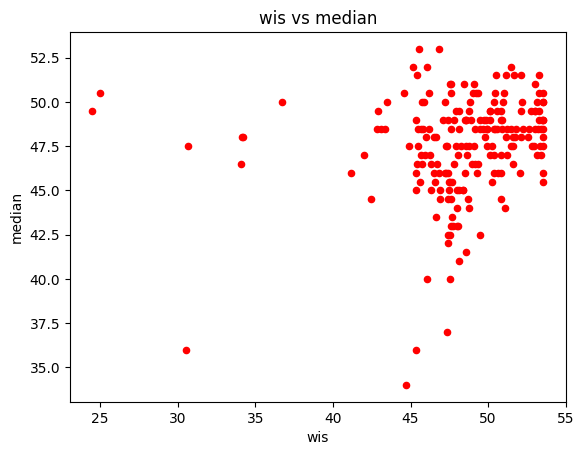

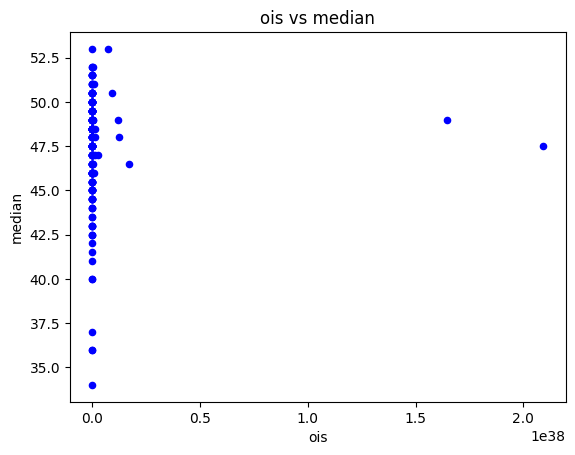

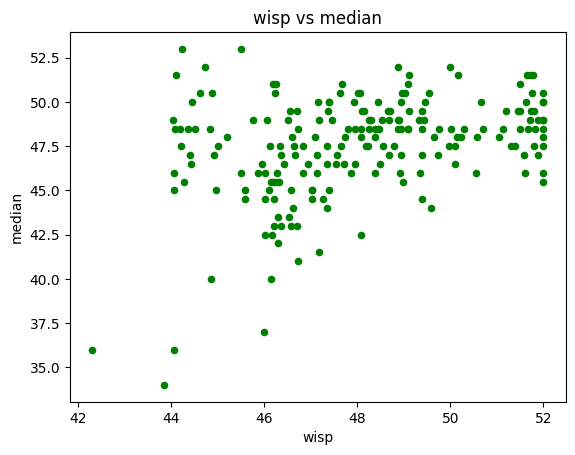

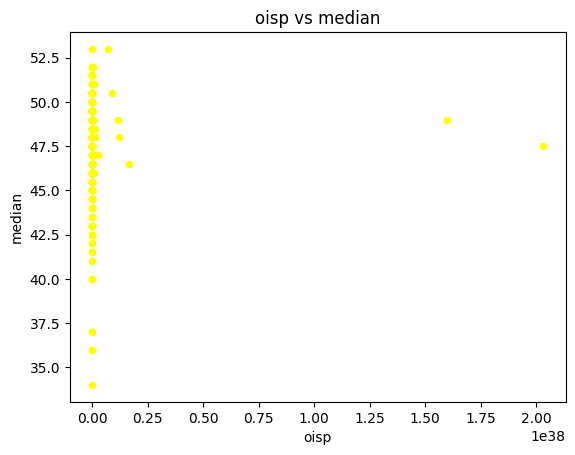

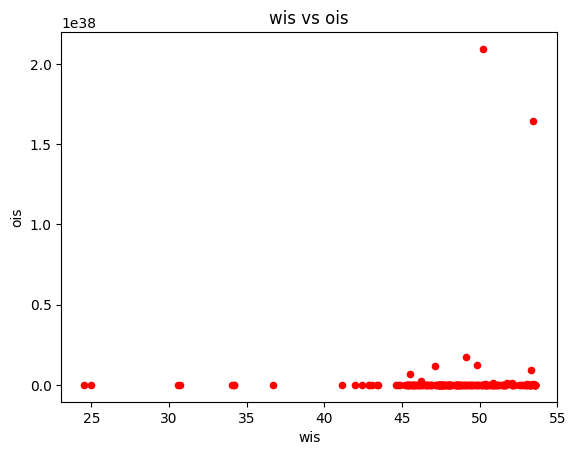

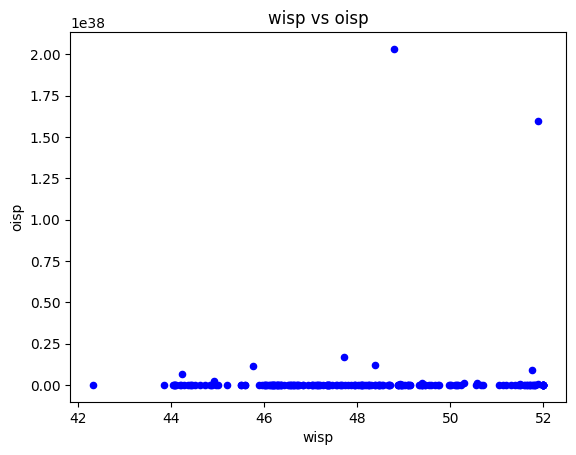

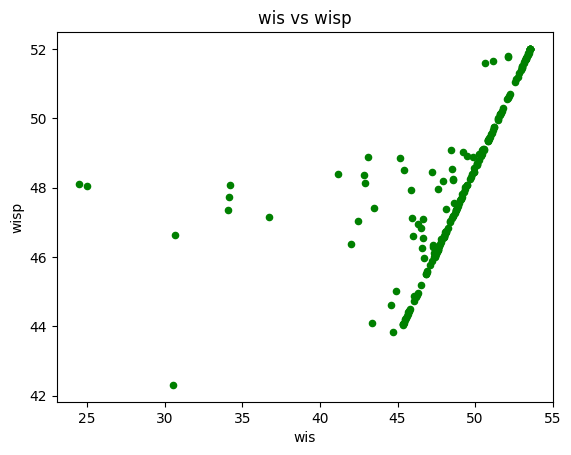

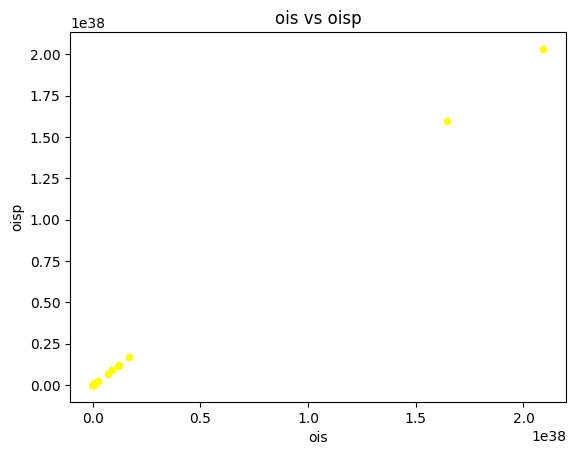

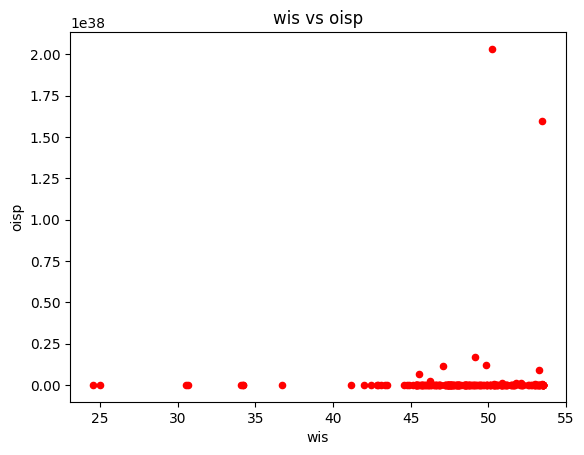

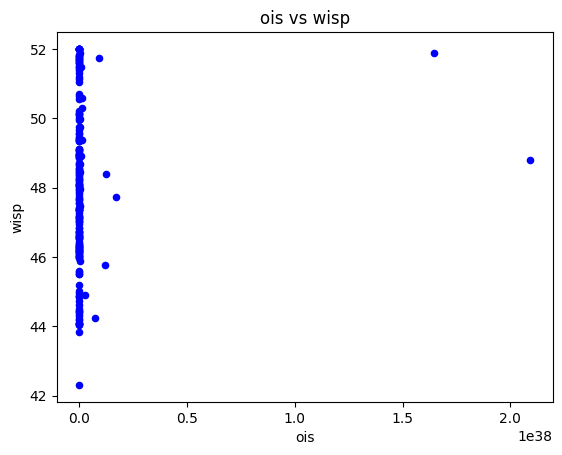

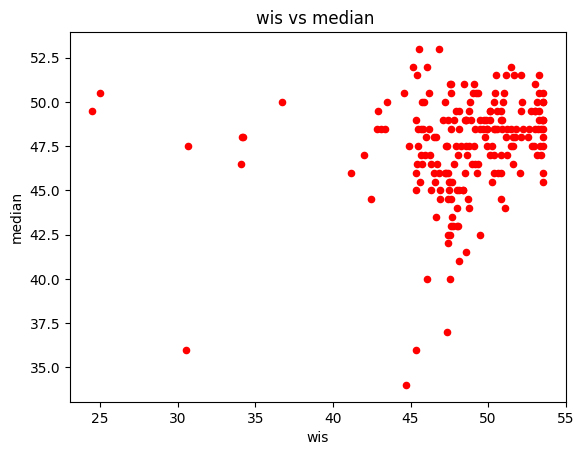

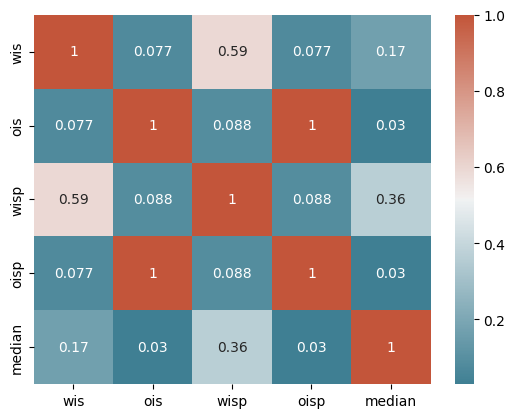

In [10]:
csv = pd.read_csv("model_data.csv")
print(csv.head())

#1. Data Visualization
# from data csv , we only keep, wis, ois, wisp, oisp and median columns
df=csv[["wis","ois","wisp","oisp","median"]]
print(df.head())
dataviz(df)

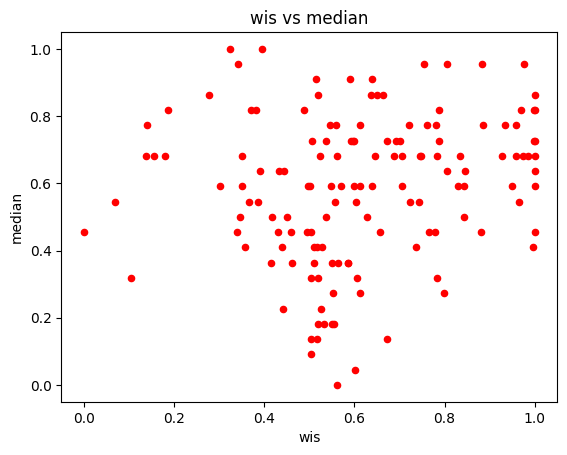

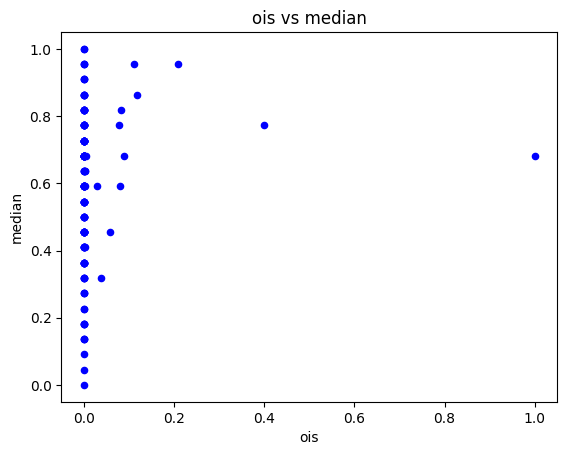

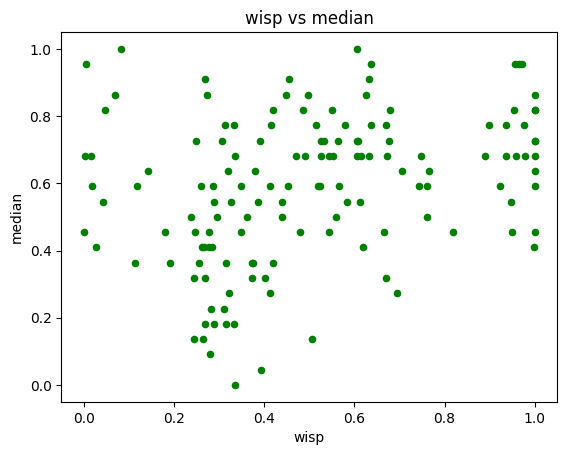

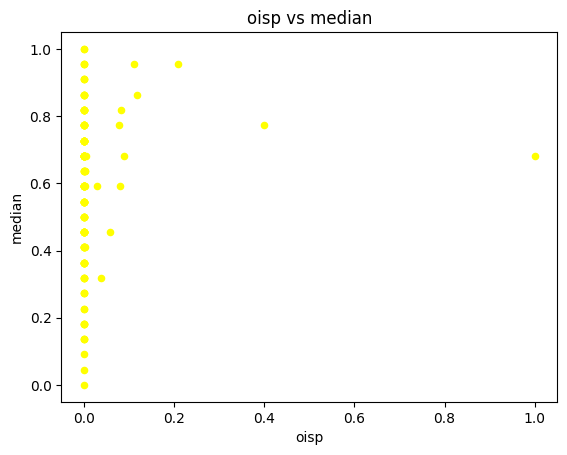

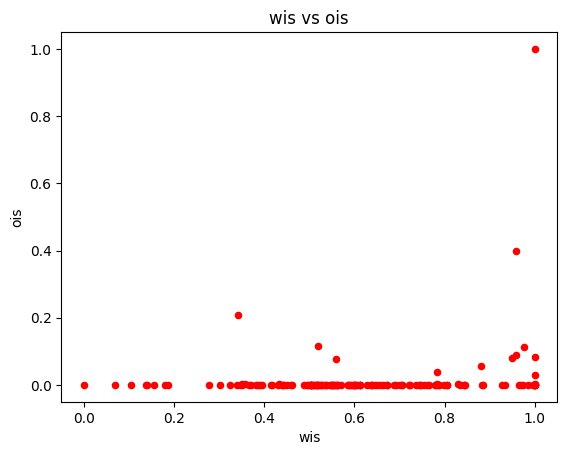

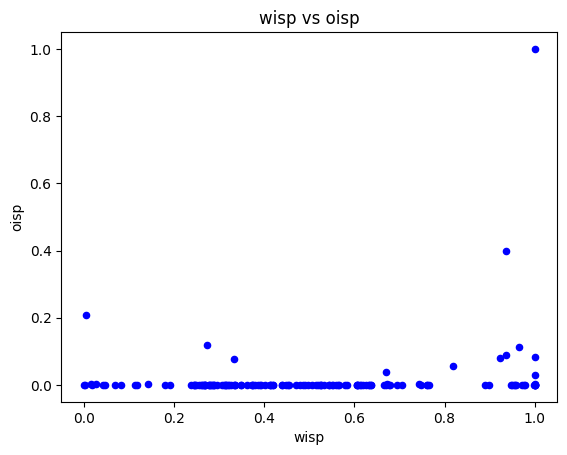

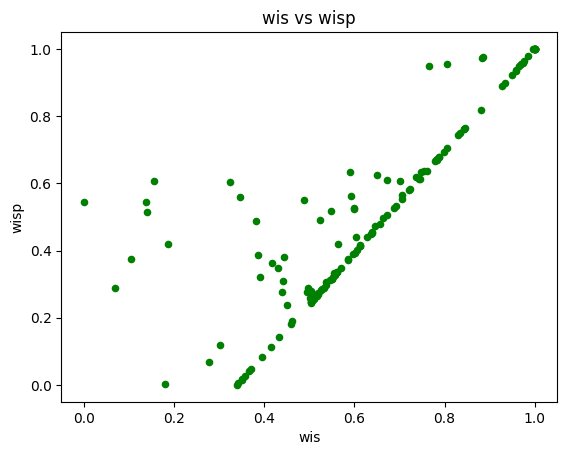

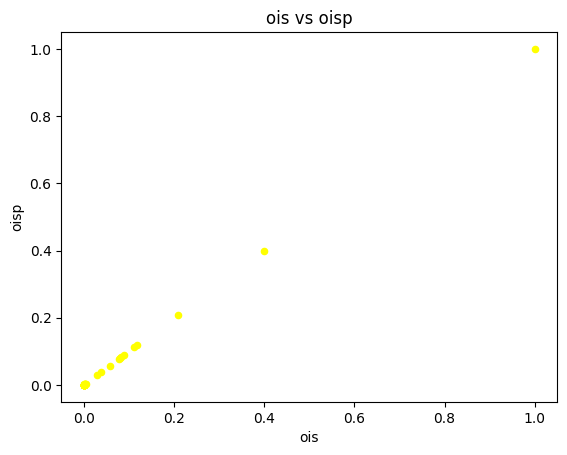

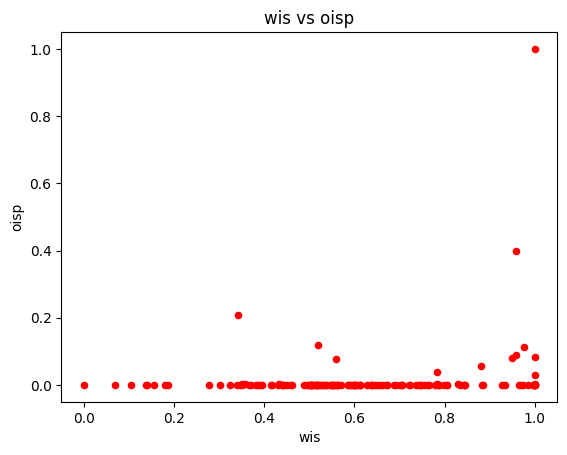

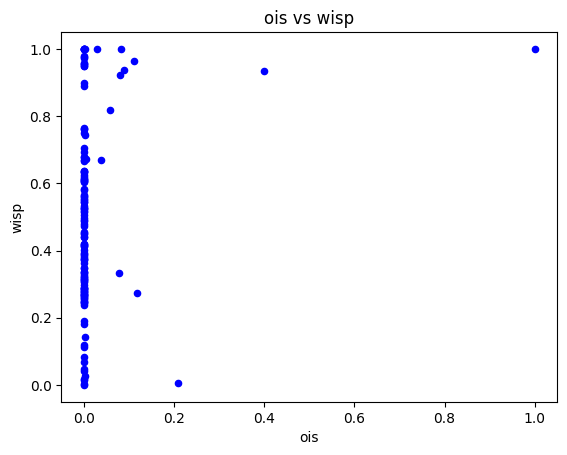

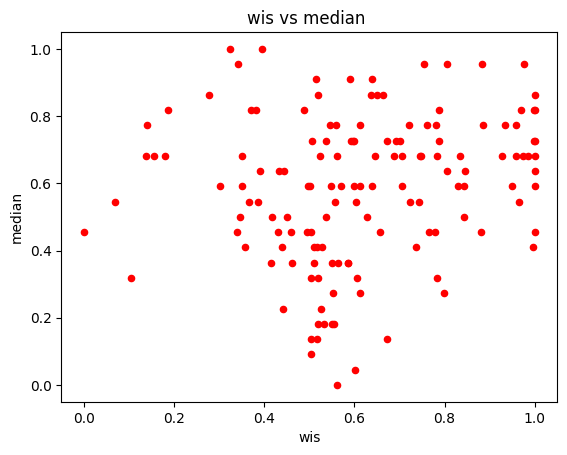

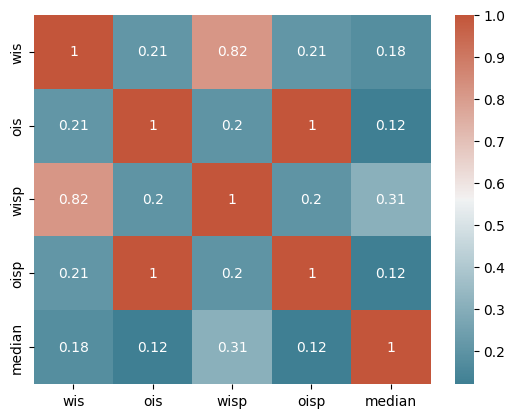

In [11]:
## 2. Data Preprocessing
# 2.1. moving outliers
def moving_outliers(df):
    """ Moving outliers from the data """
    q1 = df.quantile(0.25)
    q3 = df.quantile(0.75)
    iqr = q3 - q1
    df = df[~((df < (q1 - 1.5 * iqr)) | (df > (q3 + 1.5 * iqr))).any(axis=1)]
    return df
df = moving_outliers(df)
# 2.2. Normalization of the data
def normalization(df):
    """ Normalization of the data """
    df = (df - df.min()) / (df.max() - df.min())
    return df
df = normalization(df)

# plot the data 
dataviz(df)

In [12]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
## 3. Data Splitting
def data_splitting(df):
    """ Splitting the data into training and testing data """
    train = df.sample(frac=0.8, random_state=200)
    test = df.drop(train.index)
    return train, test

train, test = data_splitting(df)

## 4. Model Building
def model_building(train):
    """Building the polynomial regression model"""
    # Extract features and target variable
    X_train = train[['wis', 'ois', 'wisp', 'oisp']]
    y_train = train['median']
    
    # Polynomial feature transformation
    poly = PolynomialFeatures(degree=1)  # Adjust degree as necessary
    X_poly_train = poly.fit_transform(X_train)
    
    # Fit polynomial regression model
    model = LinearRegression()
    model.fit(X_poly_train, y_train)
    
    return model, poly

model, poly = model_building(train)

# Printing the model coefficients
print("Model coefficients:", model.coef_)
print("Model intercept:", model.intercept_)

# Print the polynomial equation
feature_names = poly.get_feature_names_out(['wis', 'ois', 'wisp', 'oisp'])
print("Model equation: y = ", end="")
for i, coef in enumerate(model.coef_):
    if i > 0:  # skip the intercept term
        print(f"({coef})*{feature_names[i-1]}", end=" + ")
print(f"{model.intercept_}")

Model coefficients: [ 0.00000000e+00 -1.86477545e-01 -4.68237826e+03  3.78415775e-01
  4.68237764e+03]
Model intercept: 0.5116136489011153
Model equation: y = (-0.18647754465718722)*1 + (-4682.378257307976)*wis + (0.3784157754617691)*ois + (4682.377635459471)*wisp + 0.5116136489011153


In [13]:
## 5. Model Prediction
def model_prediction(model, poly, test):
    """ Making predictions using the model """
    # Extract features and target variable
    X_test = test[['wis', 'ois', 'wisp', 'oisp']]
    y_test = test['median']
    
    # Polynomial feature transformation
    X_poly_test = poly.fit_transform(X_test)
    
    # Make predictions
    y_pred = model.predict(X_poly_test)
    
    return y_test, y_pred

y_test, y_pred = model_prediction(model, poly, test)

## 6. Model Evaluation
def model_evaluation(y_test, y_pred):
    """ Evaluating the model using RMSE """
    rmse = math.sqrt(mean_squared_error(y_test, y_pred))
    return rmse

rmse = model_evaluation(y_test, y_pred)
print("Root Mean Squared Error:", rmse)


Root Mean Squared Error: 0.20500652737523922


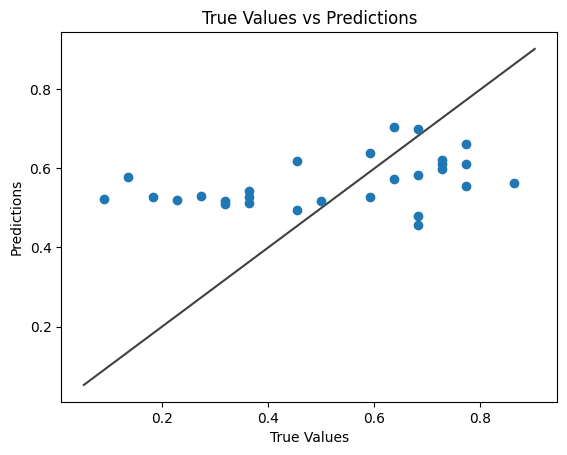

In [14]:
## 7. Model Visualization

def model_viz(y_test, y_pred):
    """ Visualizing the model predictions """
    plt.scatter(y_test, y_pred)
    plt.xlabel("True Values")
    plt.ylabel("Predictions")
    plt.title("True Values vs Predictions")

    # plot the line
    lims = [
        np.min([plt.xlim(), plt.ylim()]),  # min of both axes
        np.max([plt.xlim(), plt.ylim()]),  # max of both axes
    ]
    plt.plot(lims, lims, 'k-', alpha=0.75, zorder=0)

    # constrain the axis in [0,1]
    #plt.xlim([0,1])
    #plt.ylim([0,1])
    
    plt.show()

#remove outliers

model_viz(y_test, y_pred)